# SVG Sun Viewer

This notebook opens and displays the svg/sun.svg file.

In [82]:
# Import required libraries
import os
import re
import xml.etree.ElementTree as ET
from IPython.display import SVG, display
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


Opening SVG file: svg/sun.svg


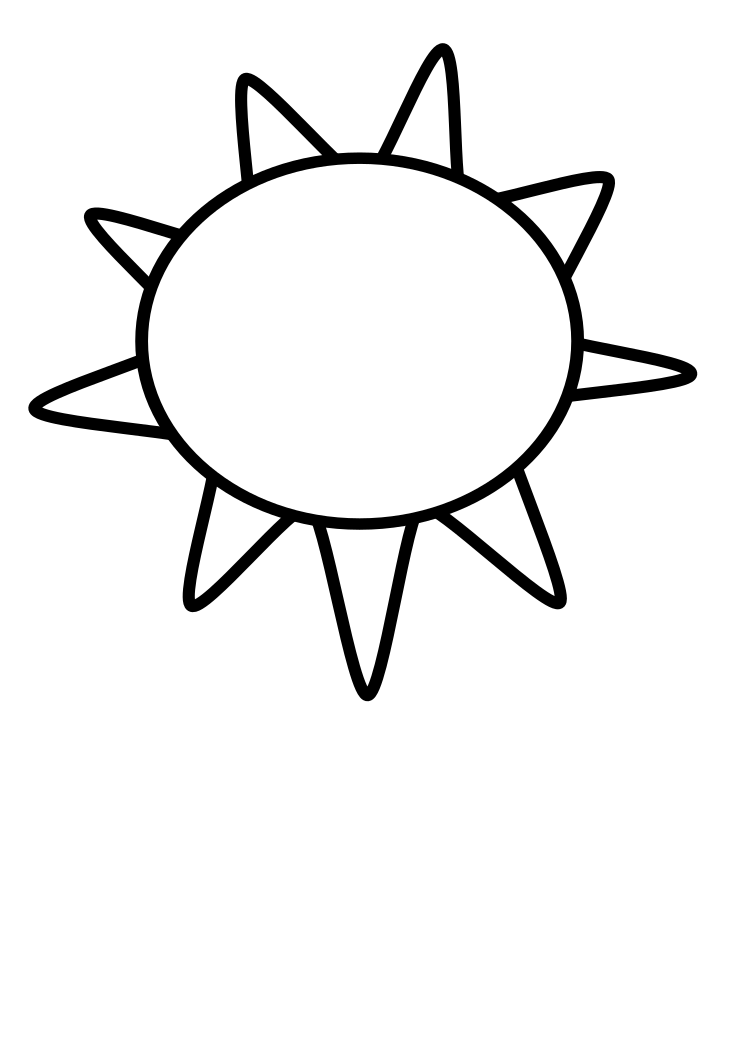


File size: 5435 characters
File path: c:\web\serial3d\svg\sun.svg


In [79]:
# Open and display svg/sun.svg file
svg_path = "svg/sun.svg"

# Check if the file exists
if os.path.exists(svg_path):
    print(f"Opening SVG file: {svg_path}")
    
    # Display the SVG file
    display(SVG(filename=svg_path))
    
    # Also read and show file info
    with open(svg_path, 'r', encoding='utf-8') as file:
        svg_content = file.read()
    
    print(f"\nFile size: {len(svg_content)} characters")
    print(f"File path: {os.path.abspath(svg_path)}")
    
else:
    print(f"Error: SVG file not found at {svg_path}")
    print(f"Current working directory: {os.getcwd()}")
    print("Please make sure the svg/sun.svg file exists in the correct location.")

In [80]:
def parse_path_data(path_data):
    """Extract coordinates from SVG path data with better parsing"""
    coords = []
    try:
        # Handle different path commands and extract all coordinate pairs
        import re
        
        # Remove path commands but keep numbers (including negative)
        # This regex finds all floating point numbers including negative ones
        numbers = re.findall(r'-?\d*\.?\d+', path_data)
        numbers = [float(n) for n in numbers if n]
        
        # Group coordinates in pairs (x, y)
        for i in range(0, len(numbers) - 1, 2):
            if i + 1 < len(numbers):
                coords.append((numbers[i], numbers[i + 1]))
    except Exception as e:
        print(f"Error parsing path data: {e}")
    
    return coords

def get_original_viewbox(svg_content):
    """Extract the original viewBox from SVG if it exists"""
    import re
    viewbox_match = re.search(r'viewBox\s*=\s*["\']([^"\']*)["\']', svg_content)
    if viewbox_match:
        viewbox_str = viewbox_match.group(1)
        try:
            parts = viewbox_str.split()
            if len(parts) == 4:
                return {
                    'x': float(parts[0]),
                    'y': float(parts[1]),
                    'width': float(parts[2]),
                    'height': float(parts[3])
                }
        except ValueError:
            pass
    return None

def get_svg_bounding_box(svg_content):
    """Calculate the bounding box of an SVG with improved parsing"""
    try:
        # First check if there's an original viewBox we can use as reference
        original_viewbox = get_original_viewbox(svg_content)
        if original_viewbox:
            print(f"Found original viewBox: {original_viewbox['x']} {original_viewbox['y']} {original_viewbox['width']} {original_viewbox['height']}")
        
        # Parse the SVG
        root = ET.fromstring(svg_content)
        
        all_coords = []
        elements_found = []
        
        # Extract coordinates from different SVG elements, including nested groups
        for elem in root.iter():
            tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
            
            # Handle transforms if present
            transform = elem.get('transform', '')
            
            if tag == 'circle':
                try:
                    cx = float(elem.get('cx', 0))
                    cy = float(elem.get('cy', 0))
                    r = float(elem.get('r', 0))
                    all_coords.extend([(cx-r, cy-r), (cx+r, cy+r)])
                    elements_found.append(f"circle: center=({cx},{cy}) radius={r}")
                except (ValueError, TypeError):
                    pass
                    
            elif tag == 'rect':
                try:
                    x = float(elem.get('x', 0))
                    y = float(elem.get('y', 0))
                    width = float(elem.get('width', 0))
                    height = float(elem.get('height', 0))
                    all_coords.extend([(x, y), (x + width, y + height)])
                    elements_found.append(f"rect: ({x},{y}) {width}x{height}")
                except (ValueError, TypeError):
                    pass
                    
            elif tag == 'ellipse':
                try:
                    cx = float(elem.get('cx', 0))
                    cy = float(elem.get('cy', 0))
                    rx = float(elem.get('rx', 0))
                    ry = float(elem.get('ry', 0))
                    all_coords.extend([(cx-rx, cy-ry), (cx+rx, cy+ry)])
                    elements_found.append(f"ellipse: center=({cx},{cy}) rx={rx} ry={ry}")
                except (ValueError, TypeError):
                    pass
                    
            elif tag == 'line':
                try:
                    x1 = float(elem.get('x1', 0))
                    y1 = float(elem.get('y1', 0))
                    x2 = float(elem.get('x2', 0))
                    y2 = float(elem.get('y2', 0))
                    all_coords.extend([(x1, y1), (x2, y2)])
                    elements_found.append(f"line: ({x1},{y1}) to ({x2},{y2})")
                except (ValueError, TypeError):
                    pass
                    
            elif tag == 'path':
                d = elem.get('d', '')
                if d:
                    path_coords = parse_path_data(d)
                    if path_coords:
                        all_coords.extend(path_coords)
                        elements_found.append(f"path: {len(path_coords)} points")
                    
            elif tag == 'polygon' or tag == 'polyline':
                points = elem.get('points', '')
                if points:
                    try:
                        coords = re.findall(r'-?\d*\.?\d+', points)
                        coords = [float(c) for c in coords if c]
                        poly_coords = []
                        for i in range(0, len(coords) - 1, 2):
                            if i + 1 < len(coords):
                                poly_coords.append((coords[i], coords[i + 1]))
                        all_coords.extend(poly_coords)
                        elements_found.append(f"{tag}: {len(poly_coords)} points")
                    except (ValueError, TypeError):
                        pass
        
        # Debug: print found elements
        print(f"Found {len(elements_found)} drawable elements:")
        for elem in elements_found[:10]:  # Show first 10
            print(f"  - {elem}")
        if len(elements_found) > 10:
            print(f"  ... and {len(elements_found) - 10} more")
            
        if not all_coords:
            print("No coordinates found in SVG elements")
            # If we have an original viewBox but no parsed coordinates, use it
            if original_viewbox:
                return {
                    'min_x': original_viewbox['x'],
                    'min_y': original_viewbox['y'],
                    'max_x': original_viewbox['x'] + original_viewbox['width'],
                    'max_y': original_viewbox['y'] + original_viewbox['height'],
                    'width': original_viewbox['width'],
                    'height': original_viewbox['height'],
                    'total_points': 0,
                    'from_original_viewbox': True
                }
            return None
            
        # Calculate bounding box from parsed coordinates
        x_coords = [coord[0] for coord in all_coords]
        y_coords = [coord[1] for coord in all_coords]
        
        min_x = min(x_coords)
        max_x = max(x_coords)
        min_y = min(y_coords)
        max_y = max(y_coords)
        
        print(f"Processed {len(all_coords)} coordinate points")
        
        result = {
            'min_x': min_x,
            'min_y': min_y,
            'max_x': max_x,
            'max_y': max_y,
            'width': max_x - min_x,
            'height': max_y - min_y,
            'total_points': len(all_coords),
            'from_original_viewbox': False
        }
        
        # Compare with original viewBox if available
        if original_viewbox:
            print(f"Calculated bbox vs original viewBox:")
            print(f"  Calculated: {min_x:.1f}, {min_y:.1f}, {max_x - min_x:.1f}x{max_y - min_y:.1f}")
            print(f"  Original:   {original_viewbox['x']:.1f}, {original_viewbox['y']:.1f}, {original_viewbox['width']:.1f}x{original_viewbox['height']:.1f}")
            
            # If original viewBox is significantly larger, prefer it
            if (original_viewbox['width'] > result['width'] * 1.2 or 
                original_viewbox['height'] > result['height'] * 1.2):
                print("Using original viewBox as it appears more comprehensive")
                return {
                    'min_x': original_viewbox['x'],
                    'min_y': original_viewbox['y'],
                    'max_x': original_viewbox['x'] + original_viewbox['width'],
                    'max_y': original_viewbox['y'] + original_viewbox['height'],
                    'width': original_viewbox['width'],
                    'height': original_viewbox['height'],
                    'total_points': len(all_coords),
                    'from_original_viewbox': True
                }
        
        return result
        
    except Exception as e:
        print(f"Error parsing SVG: {e}")
        import traceback
        traceback.print_exc()
        return None

print("Enhanced SVG bounding box functions defined")

Enhanced SVG bounding box functions defined


SVG WITH BOUNDING BOX VISUALIZATION
Found original viewBox: 0.0 0.0 744.09 1052.4
Found 2 drawable elements:
  - path: 53 points
  - path: 10 points
Processed 63 coordinate points
Calculated bbox vs original viewBox:
  Calculated: -39.9, -37.4, 350.6x169.5
  Original:   0.0, 0.0, 744.1x1052.4
Using original viewBox as it appears more comprehensive
Bounding box: (0.0, 0.0) to (744.1, 1052.4)
Size: 744.1 x 1052.4
ViewBox adjusted to: -30.0 -30.0 804.1 1112.4
Displaying SVG with bounding box:


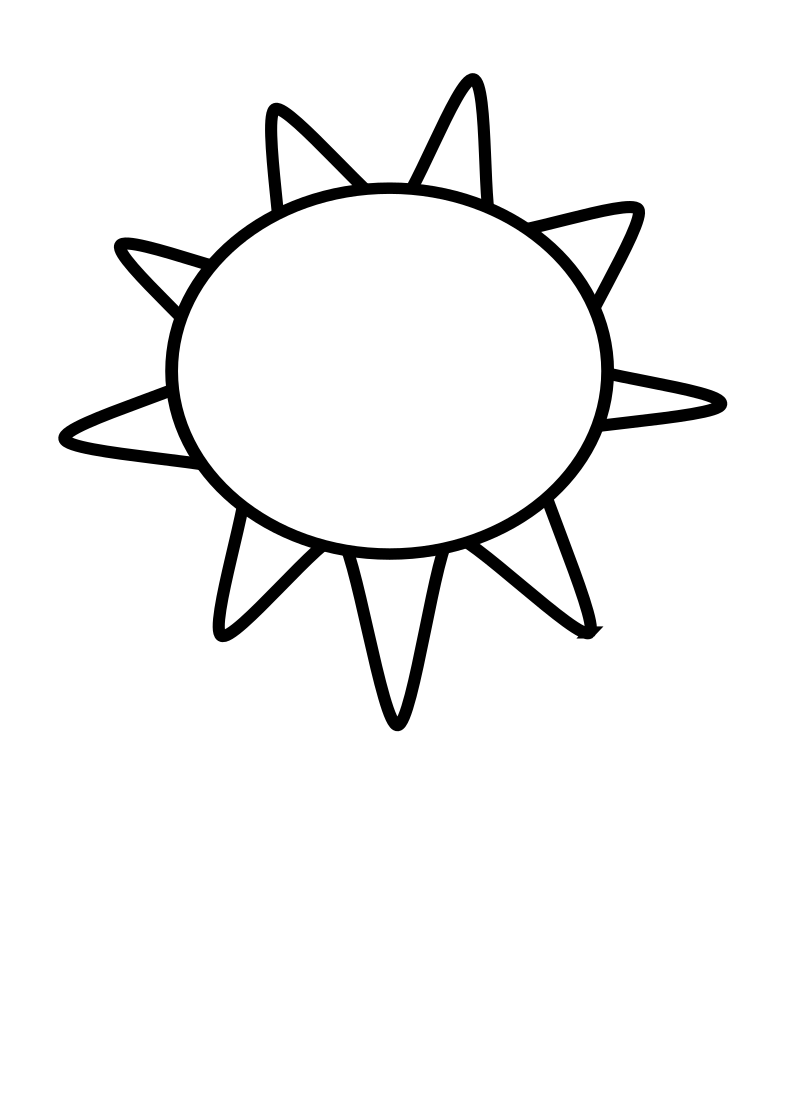


Saved result as: svg/sun_with_bbox.svg


In [83]:
# Calculate bounding box and display SVG with bounding box visualization
if os.path.exists(svg_path):
    print("SVG WITH BOUNDING BOX VISUALIZATION")
    print("=" * 40)
    
    # Read the original SVG content
    with open(svg_path, 'r', encoding='utf-8') as file:
        original_svg = file.read()
    
    # Calculate bounding box from SVG content
    bbox = get_svg_bounding_box(original_svg)
    
    if bbox:
        print(f"Bounding box: ({bbox['min_x']:.1f}, {bbox['min_y']:.1f}) to ({bbox['max_x']:.1f}, {bbox['max_y']:.1f})")
        print(f"Size: {bbox['width']:.1f} x {bbox['height']:.1f}")
        
        # Create viewBox that includes the bounding box area (including negative coordinates)
        padding = 30
        new_x = bbox['min_x'] - padding
        new_y = bbox['min_y'] - padding
        new_width = max(744.09, bbox['max_x'] + padding) - new_x
        new_height = max(1052.4, bbox['max_y'] + padding) - new_y
        new_viewbox = f"{new_x:.1f} {new_y:.1f} {new_width:.1f} {new_height:.1f}"
        
        # Create SVG with adjusted viewBox
        result_svg = original_svg
        
        # Update viewBox to include negative coordinates
        if 'viewBox=' in result_svg:
            result_svg = re.sub(r'viewBox="[^"]*"', f'viewBox="{new_viewbox}"', result_svg)
            result_svg = re.sub(r"viewBox='[^']*'", f"viewBox='{new_viewbox}'", result_svg)
        else:
            result_svg = re.sub(r'<svg([^>]*?)>', f'<svg\\1 viewBox="{new_viewbox}">', result_svg)
        
        # Set display size
        result_svg = re.sub(r'width="[^"]*"', 'width="600"', result_svg)
        result_svg = re.sub(r"width='[^']*'", "width='600'", result_svg)
        result_svg = re.sub(r'height="[^"]*"', 'height="400"', result_svg)
        result_svg = re.sub(r"height='[^']*'", "height='400'", result_svg)
        
        # Add bounding box visualization
        bbox_overlay = f'''
    <!-- Bounding Box Visualization -->
    <rect x="{bbox['min_x']:.1f}" y="{bbox['min_y']:.1f}" 
          width="{bbox['width']:.1f}" height="{bbox['height']:.1f}" 
          fill="none" stroke="red" stroke-width="4" stroke-dasharray="10,5" opacity="0.9"/>
    <circle cx="{bbox['min_x']:.1f}" cy="{bbox['min_y']:.1f}" r="4" fill="red"/>
    <circle cx="{bbox['max_x']:.1f}" cy="{bbox['min_y']:.1f}" r="4" fill="red"/>
    <circle cx="{bbox['min_x']:.1f}" cy="{bbox['max_y']:.1f}" r="4" fill="red"/>
    <circle cx="{bbox['max_x']:.1f}" cy="{bbox['max_y']:.1f}" r="4" fill="red"/>
    <text x="{bbox['min_x']:.1f}" y="{bbox['min_y'] - 10:.1f}" 
          font-family="Arial" font-size="14" font-weight="bold" fill="red">
        Bounding Box: {bbox['width']:.0f}×{bbox['height']:.0f}
    </text>'''
        
        # Insert bounding box before closing </svg> tag
        result_svg = result_svg.replace('</svg>', bbox_overlay + '\n</svg>')
        
        print(f"ViewBox adjusted to: {new_viewbox}")
        print("Displaying SVG with bounding box:")
        
        display(SVG(data=result_svg))
        
        # Save result
        output_path = svg_path.replace('.svg', '_with_bbox.svg')
        with open(output_path, 'w', encoding='utf-8') as file:
            file.write(result_svg)
        print(f"\nSaved result as: {output_path}")
        
    else:
        print("Could not calculate bounding box for the SVG")
        
else:
    print(f"SVG file not found: {svg_path}")